# Credit Risk Scoring — End-to-End Data Science Project

---

## 🎯 Business Context

Banks lose **billions annually** to loan defaults. The challenge: approve good borrowers while rejecting risky ones.

**This project builds a production-grade credit scoring system that:**
- Predicts the probability of default for each applicant
- Explains every individual decision (GDPR / Basel III compliance)
- Optimizes the approval threshold based on real business costs
- Is deployable as a web application for credit officers

| Metric | Description |
|--------|-------------|
| **Target** | Binary: Good Credit (1) vs Bad Credit (0) |
| **Primary KPI** | Gini Coefficient (banking industry standard) |
| **Secondary KPI** | AUC-ROC, Cost-sensitive accuracy |
| **Dataset** | 1,000 applicants, 20 features |

---
## 1 — Setup & Imports

In [1]:
# ── Core ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

# ── Statistics ────────────────────────────────────────────────────────
from scipy.stats import chi2_contingency, pointbiserialr, ks_2samp, mannwhitneyu

# ── Preprocessing ─────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ── Models ────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Evaluation ────────────────────────────────────────────────────────
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)

# ── Interpretability ──────────────────────────────────────────────────
import shap
shap.initjs()

import pickle, os
print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


---
## 2 — Data Loading & First Look

In [5]:
# Load German Credit Dataset
dataset = '/kaggle/input/datasets/kabure/german-credit-data-with-risk/german_credit_data.csv'
df = pd.read_csv(dataset, index_col=0)

# Encode target: Good=1, Bad=0
if 'Risk' in df.columns:
    df['Risk'] = (df['Risk'] == 'good').astype(int)

print(f'Shape: {df.shape}')
print(f'\nTarget distribution:\n{df["Risk"].value_counts()}')
df.head()

Shape: (1000, 10)

Target distribution:
Risk
1    700
0    300
Name: count, dtype: int64


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,0
2,49,male,1,own,little,NaN,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,0


In [6]:
# ── Data Quality Report ─────────────────────────────────────────────
quality = pd.DataFrame({
    'dtype':    df.dtypes,
    'missing':  df.isnull().sum(),
    'missing%': (df.isnull().mean() * 100).round(2),
    'unique':   df.nunique(),
})
print('📋 Data Quality Report')
quality

📋 Data Quality Report


,dtype,missing,missing%,unique
Age,int64,0,0.0,53
Sex,object,0,0.0,2
Job,int64,0,0.0,4
Housing,object,0,0.0,3
Saving accounts,object,183,18.3,4
Checking account,object,394,39.4,3
Credit amount,int64,0,0.0,921
Duration,int64,0,0.0,33
Purpose,object,0,0.0,8
Risk,int64,0,0.0,2


---
## 📊 Section 3 — Exploratory Data Analysis & Statistics

We go beyond simple plots — we use **statistical tests** to rigorously identify
which features truly discriminate between good and bad credit risk.

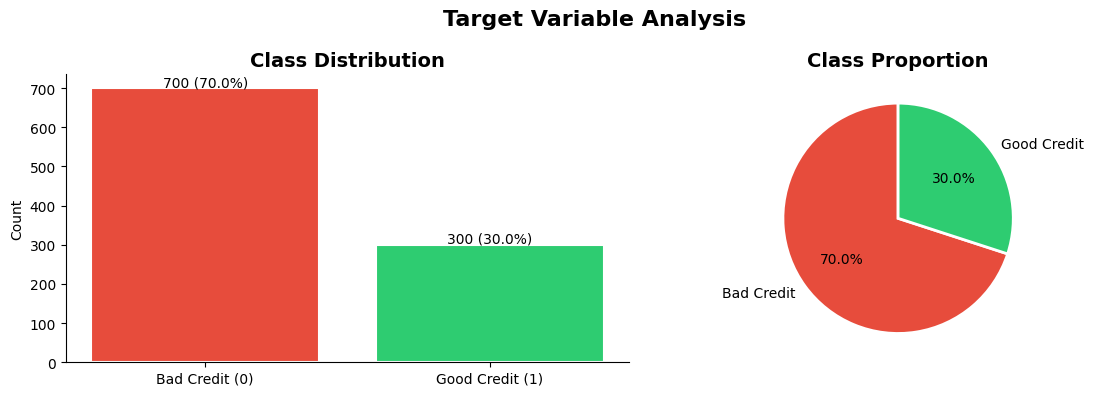

Imbalance ratio (Bad:Good) = 0.43
→ We will use class_weight="balanced" and evaluate with AUC, not accuracy.


In [7]:
# ── Class Balance ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Risk'].value_counts()
axes[0].bar(['Bad Credit (0)', 'Good Credit (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v} ({v/len(df)*100:.1f}%)', ha='center')

axes[1].pie(counts.values, labels=['Bad Credit', 'Good Credit'],
            colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')
plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Imbalance ratio (Bad:Good) = {counts[0]/counts[1]:.2f}')
print('→ We will use class_weight="balanced" and evaluate with AUC, not accuracy.')

In [8]:
# ── Numerical Features — Statistical Tests ──────────────────────────
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Risk' in numerical_cols:
    numerical_cols.remove('Risk')

stat_results = []
for col in numerical_cols:
    good = df[df['Risk'] == 1][col].dropna()
    bad  = df[df['Risk'] == 0][col].dropna()
    corr, p_corr = pointbiserialr(df[col].dropna(), df.loc[df[col].notna(), 'Risk'])
    ks_stat, p_ks = ks_2samp(good, bad)
    _, p_mw = mannwhitneyu(good, bad, alternative='two-sided')
    stat_results.append({
        'Feature':        col,
        'Mean (Good)':    round(good.mean(), 2),
        'Mean (Bad)':     round(bad.mean(), 2),
        'PB Correlation': round(corr, 3),
        'KS Statistic':   round(ks_stat, 3),
        'KS p-value':     round(p_ks, 4),
        'MW p-value':     round(p_mw, 4),
        'Significant':    '✅' if p_ks < 0.05 else '❌'
    })

stat_df = pd.DataFrame(stat_results).sort_values('KS Statistic', ascending=False)
print('📐 Statistical Tests — Numerical Features vs Credit Risk')
print('KS p-value < 0.05 → distributions significantly differ between classes')
stat_df

📐 Statistical Tests — Numerical Features vs Credit Risk
KS p-value < 0.05 → distributions significantly differ between classes


,Feature,Mean (Good),Mean (Bad),PB Correlation,KS Statistic,KS p-value,MW p-value,Significant
3,Duration,19.21,24.86,-0.215,0.192,0.0000,0.0000,✅
2,Credit amount,2985.46,3938.13,-0.155,0.157,0.0001,0.0059,✅
0,Age,36.22,33.96,0.091,0.131,0.0013,0.0004,✅
1,Job,1.89,1.94,-0.033,0.031,0.9818,0.2642,❌


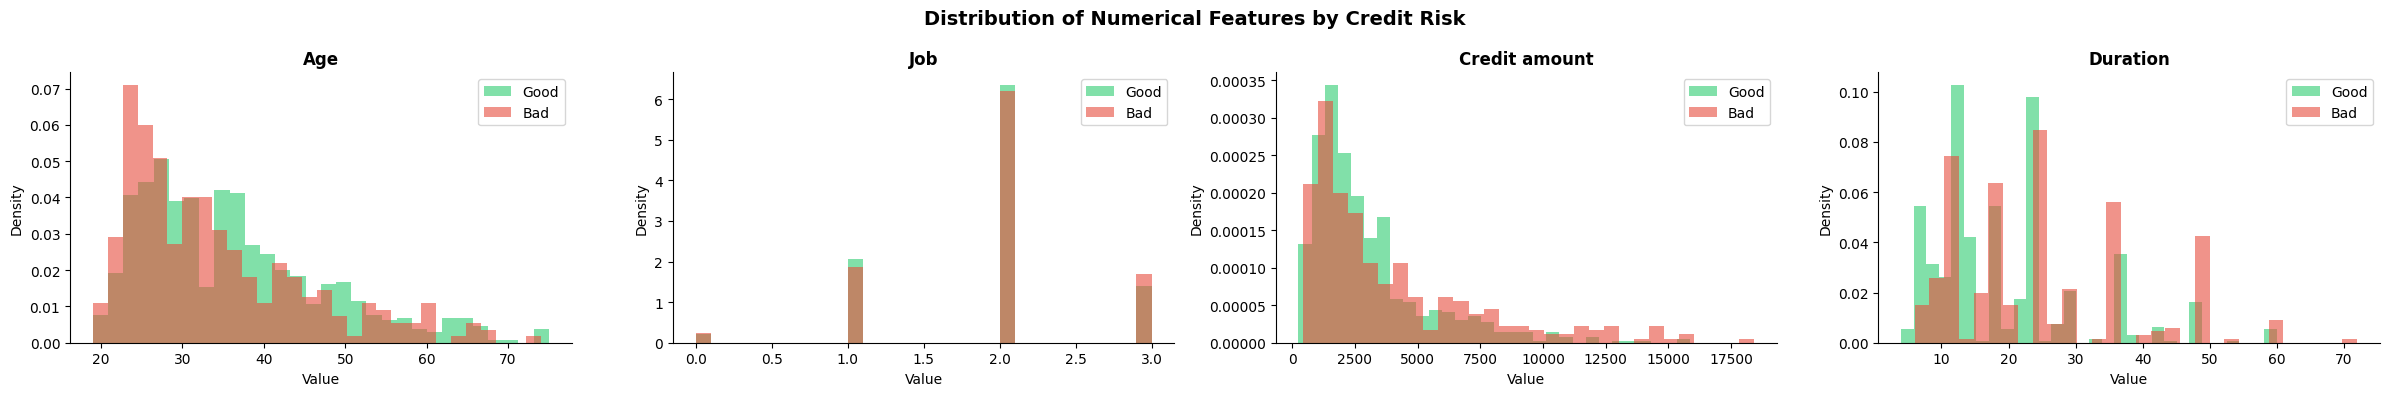

In [9]:
# ── Distribution by Risk Class ──────────────────────────────────────
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(6*len(numerical_cols), 4))
if len(numerical_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numerical_cols):
    for risk, color, label in [(1, '#2ecc71', 'Good'), (0, '#e74c3c', 'Bad')]:
        ax.hist(df[df['Risk']==risk][col], bins=30, alpha=0.6,
                color=color, label=label, density=True)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()
plt.suptitle('Distribution of Numerical Features by Credit Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ── Categorical Features — Cramér's V & Chi-Squared ─────────────────
categorical_cols = df.select_dtypes(include='object').columns.tolist()

def cramers_v(x, y):
    cm = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(cm)
    n = cm.sum().sum()
    r, k = cm.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1)))), p

cat_results = []
for col in categorical_cols:
    v, p = cramers_v(df[col], df['Risk'])
    bad_rate = df.groupby(col)['Risk'].apply(lambda x: (x==0).mean())
    cat_results.append({
        'Feature':      col,
        "Cramér's V":   round(v, 3),
        'Chi2 p-value': round(p, 4),
        'Min Bad Rate': f'{bad_rate.min():.1%}',
        'Max Bad Rate': f'{bad_rate.max():.1%}',
        'Significant':  '✅' if p < 0.05 else '❌'
    })

cat_df = pd.DataFrame(cat_results).sort_values("Cramér's V", ascending=False)
print("📐 Cramér's V — Categorical Features vs Credit Risk")
print("Cramér's V > 0.15 → meaningful association")
cat_df

📐 Cramér's V — Categorical Features vs Credit Risk
Cramér's V > 0.15 → meaningful association


,Feature,Cramér's V,Chi2 p-value,Min Bad Rate,Max Bad Rate,Significant
3,Checking account,0.168,0.0002,22.2%,49.3%,✅
2,Saving accounts,0.150,0.0004,12.5%,36.0%,✅
1,Housing,0.135,0.0001,26.1%,40.7%,✅
4,Purpose,0.117,0.0579,22.1%,41.7%,❌
0,Sex,0.073,0.0207,27.7%,35.2%,✅


---
## 4 — Feature Engineering

We use techniques from **real bank scorecard development**, including
Weight of Evidence (WoE) encoding — the industry standard.

In [11]:
df_fe = df.copy()

# ── 1. Financial Ratios ───────────────────────────────────────────────
df_fe['monthly_installment'] = df_fe['Credit amount'] / df_fe['Duration']
df_fe['credit_per_age']      = df_fe['Credit amount'] / df_fe['Age']
df_fe['duration_age_ratio']  = df_fe['Duration']      / df_fe['Age']

# ── 2. Age Risk Bins (scorecard practice) ────────────────────────────
df_fe['age_group'] = pd.cut(df_fe['Age'],
    bins=[0, 25, 35, 50, 100],
    labels=['Young (18-25)', 'Adult (26-35)', 'Middle (36-50)', 'Senior (50+)'])

# ── 3. Credit Amount Bins ─────────────────────────────────────────────
df_fe['credit_band'] = pd.qcut(df_fe['Credit amount'], q=4,
    labels=['Low', 'Medium', 'High', 'Very High'])

print('✅ Engineered features: monthly_installment, credit_per_age, duration_age_ratio, age_group, credit_band')
df_fe[['monthly_installment','credit_per_age','duration_age_ratio','age_group','credit_band']].head()

✅ Engineered features: monthly_installment, credit_per_age, duration_age_ratio, age_group, credit_band


,monthly_installment,credit_per_age,duration_age_ratio,age_group,credit_band
0,194.833333,17.447761,0.089552,Senior (50+),Low
1,123.979167,270.500000,2.181818,Young (18-25),Very High
2,174.666667,42.775510,0.244898,Middle (36-50),Medium
3,187.666667,175.155556,0.933333,Middle (36-50),Very High
4,202.916667,91.886792,0.452830,Senior (50+),Very High


In [12]:
# ── Weight of Evidence (WoE) & Information Value (IV) ────────────────
# Industry standard in bank credit scorecard development

def calc_woe_iv(df, feature, target='Risk', epsilon=1e-6):
    """
    IV Guide:
      < 0.02  → Useless
      0.02-0.1 → Weak
      0.1-0.3  → Medium
      0.3-0.5  → Strong
      > 0.5    → Suspicious (possible leakage!)
    """
    total_good = (df[target] == 1).sum()
    total_bad  = (df[target] == 0).sum()
    grouped = df.groupby(feature)[target].agg(
        good=lambda x: (x==1).sum(),
        bad=lambda x:  (x==0).sum()
    ).reset_index()
    grouped['dist_good'] = grouped['good'] / total_good
    grouped['dist_bad']  = grouped['bad']  / total_bad
    grouped['woe']       = np.log((grouped['dist_good']+epsilon)/(grouped['dist_bad']+epsilon))
    grouped['iv_part']   = (grouped['dist_good'] - grouped['dist_bad']) * grouped['woe']
    return grouped, grouped['iv_part'].sum()

woe_features = categorical_cols + ['age_group', 'credit_band']
iv_summary = []
for feat in woe_features:
    try:
        _, iv = calc_woe_iv(df_fe, feat)
        strength = ('Useless' if iv < 0.02 else 'Weak' if iv < 0.10
                    else 'Medium' if iv < 0.30 else 'Strong' if iv < 0.50 else '⚠️ Suspicious')
        iv_summary.append({'Feature': feat, 'IV': round(iv, 4), 'Strength': strength})
    except: pass

iv_df = pd.DataFrame(iv_summary).sort_values('IV', ascending=False)
print('📊 Information Value (IV) Summary')
iv_df

📊 Information Value (IV) Summary


,Feature,IV,Strength
3,Checking account,0.2616,Medium
6,credit_band,0.1273,Medium
2,Saving accounts,0.1192,Medium
5,age_group,0.0882,Weak
1,Housing,0.0833,Weak
4,Purpose,0.0673,Weak
0,Sex,0.0265,Weak


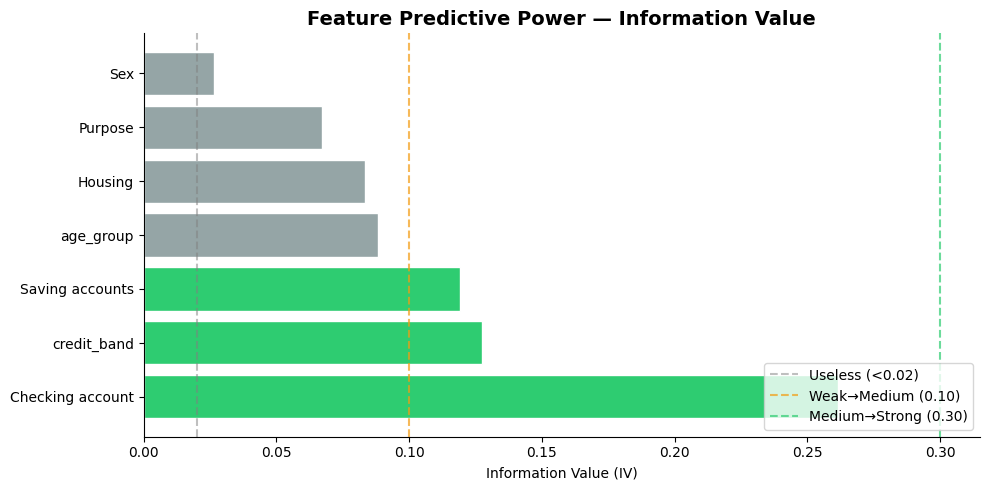

In [13]:
# IV Bar Chart
colors = ['#e74c3c' if iv > 0.5 else '#f39c12' if iv > 0.3
          else '#2ecc71' if iv > 0.1 else '#95a5a6' for iv in iv_df['IV']]

plt.figure(figsize=(10, 5))
plt.barh(iv_df['Feature'], iv_df['IV'], color=colors, edgecolor='white')
plt.axvline(0.02, color='gray',    linestyle='--', alpha=0.5, label='Useless (<0.02)')
plt.axvline(0.10, color='#f39c12', linestyle='--', alpha=0.7, label='Weak→Medium (0.10)')
plt.axvline(0.30, color='#2ecc71', linestyle='--', alpha=0.7, label='Medium→Strong (0.30)')
plt.xlabel('Information Value (IV)')
plt.title('Feature Predictive Power — Information Value', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 5 — Modeling & Evaluation

In [14]:
# ── Preprocessing ────────────────────────────────────────────────────
df_model = df_fe.copy()
df_model.drop(columns=['age_group','credit_band'], inplace=True, errors='ignore')

le = LabelEncoder()
for col in df_model.select_dtypes('object').columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop('Risk', axis=1)
y = df_model['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train class balance: {y_train.value_counts().to_dict()}')

Train: (800, 12) | Test: (200, 12)
Train class balance: {1: 560, 0: 240}


In [15]:
# ── Train & Compare 6 Models ─────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.05, scale_pos_weight=2,
                                         use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM':            LGBMClassifier(n_estimators=200, learning_rate=0.05, class_weight='balanced',
                                          random_state=42, verbose=-1)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    gini   = 2 * auc - 1   # Gini = 2*AUC - 1  ← banking KPI
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc').mean()
    results[name] = {'AUC-ROC': round(auc,4), 'Gini': round(gini,4), 'CV AUC': round(cv_auc,4)}
    print(f'{name:25s} | AUC={auc:.4f} | Gini={gini:.4f} | CV_AUC={cv_auc:.4f}')

results_df = pd.DataFrame(results).T.sort_values('Gini', ascending=False)
print(f'\n🏆 Best model: {results_df.index[0]}')
results_df

Logistic Regression       | AUC=0.7410 | Gini=0.4819 | CV_AUC=0.7329
Decision Tree             | AUC=0.6933 | Gini=0.3865 | CV_AUC=0.6643
Random Forest             | AUC=0.7355 | Gini=0.4710 | CV_AUC=0.7581
Gradient Boosting         | AUC=0.7220 | Gini=0.4440 | CV_AUC=0.7515
XGBoost                   | AUC=0.7279 | Gini=0.4557 | CV_AUC=0.7450
LightGBM                  | AUC=0.7194 | Gini=0.4388 | CV_AUC=0.7422

🏆 Best model: Logistic Regression


,AUC-ROC,Gini,CV AUC
Logistic Regression,0.7410,0.4819,0.7329
Random Forest,0.7355,0.4710,0.7581
XGBoost,0.7279,0.4557,0.7450
Gradient Boosting,0.7220,0.4440,0.7515
LightGBM,0.7194,0.4388,0.7422
Decision Tree,0.6933,0.3865,0.6643


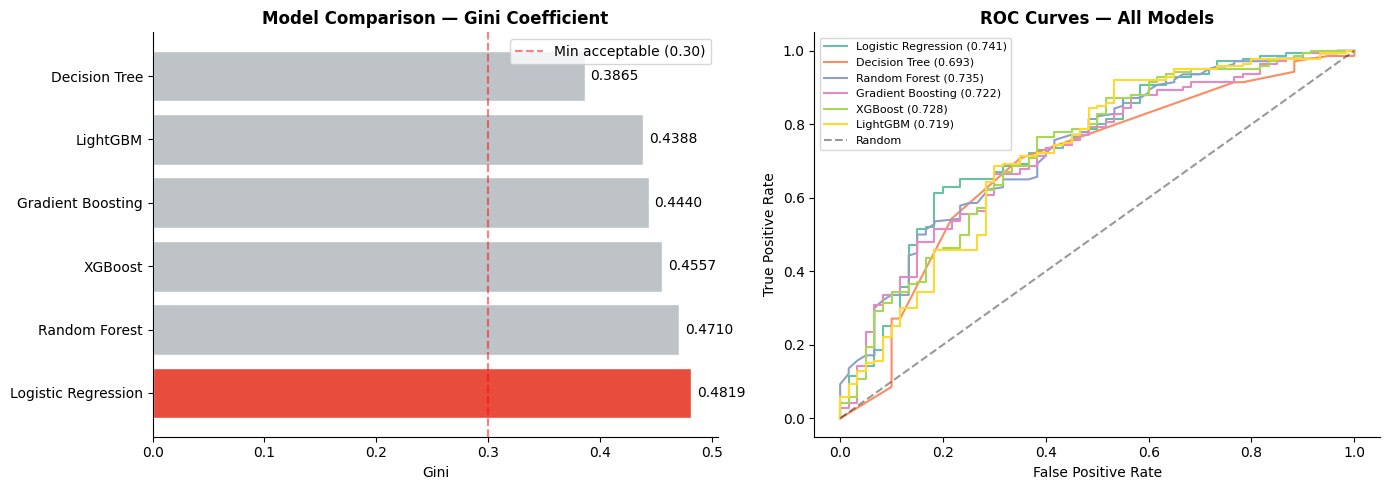

In [16]:
# ── ROC Curves for All Models ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_list = ['#e74c3c' if i==0 else '#bdc3c7' for i in range(len(results_df))]
axes[0].barh(results_df.index, results_df['Gini'], color=colors_list, edgecolor='white')
axes[0].axvline(0.3, color='red', linestyle='--', alpha=0.5, label='Min acceptable (0.30)')
for i, v in enumerate(results_df['Gini']):
    axes[0].text(v+0.005, i, f'{v:.4f}', va='center')
axes[0].set_title('Model Comparison — Gini Coefficient', fontweight='bold')
axes[0].set_xlabel('Gini')
axes[0].legend()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'{name} ({auc:.3f})', linewidth=1.5)
axes[1].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

🏆 Best Model: Logistic Regression
              precision    recall  f1-score   support

         Bad       0.47      0.68      0.56        60
        Good       0.83      0.67      0.74       140

    accuracy                           0.68       200
   macro avg       0.65      0.68      0.65       200
weighted avg       0.72      0.68      0.69       200



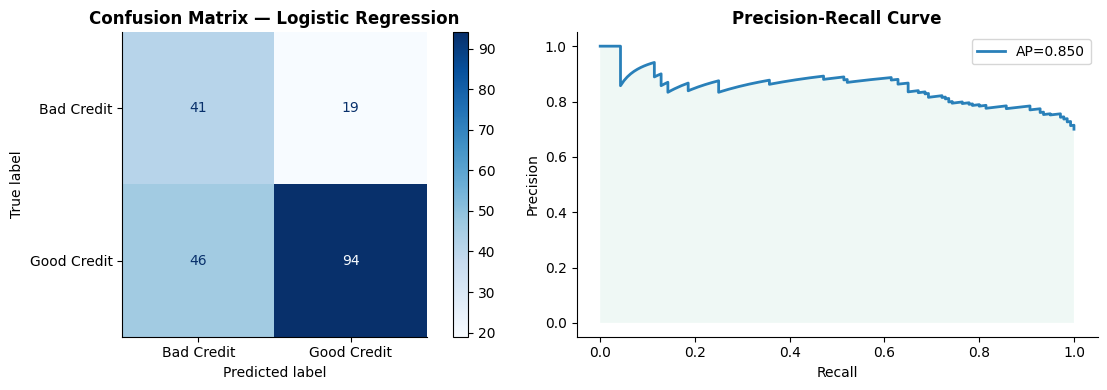

In [17]:
# ── Best Model Full Evaluation ───────────────────────────────────────
best_name   = results_df.index[0]
best_model  = models[best_name]
y_prob_best = best_model.predict_proba(X_test)[:, 1]
y_pred_best = best_model.predict(X_test)

print(f'🏆 Best Model: {best_name}')
print('='*50)
print(classification_report(y_test, y_pred_best, target_names=['Bad','Good']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best,
    display_labels=['Bad Credit','Good Credit'], cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')

prec, rec, _ = precision_recall_curve(y_test, y_prob_best)
ap = average_precision_score(y_test, y_prob_best)
axes[1].plot(rec, prec, color='#2980b9', linewidth=2, label=f'AP={ap:.3f}')
axes[1].fill_between(rec, prec, alpha=0.1)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

---
## 6 — Business Impact & Optimal Threshold

In banking, **not all errors are equal**:
- **False Negative** (missed default) → bank absorbs the loan loss
- **False Positive** (rejected good client) → bank loses interest revenue

We find the threshold that **maximises net business value**.

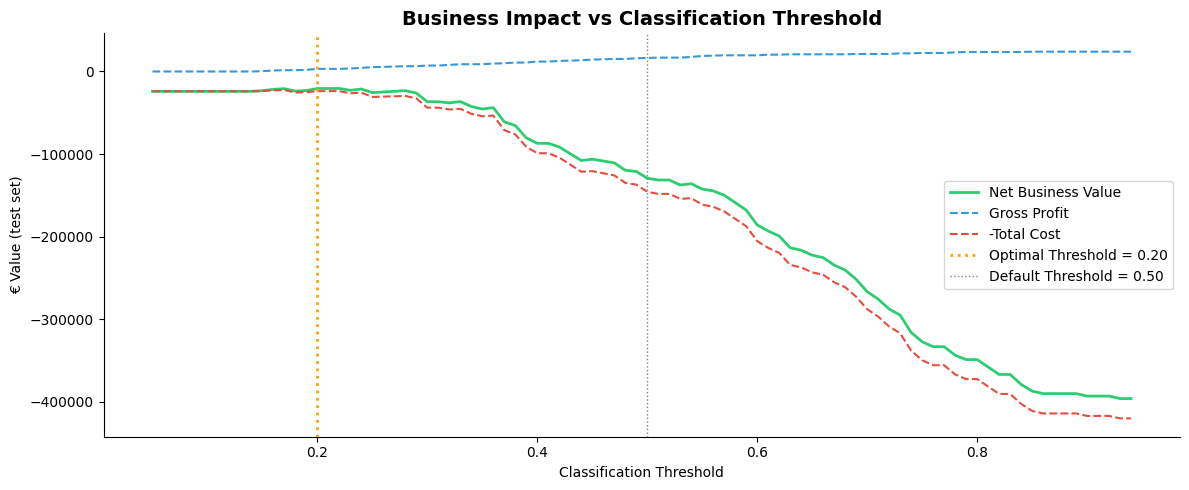

📍 Optimal threshold:    0.20
💰 Max net value:        €-20,600 (on 200 test applicants)
📈 Per 1,000 applicants: €-103,000


In [18]:
# ── Cost-Sensitive Threshold Optimization ────────────────────────────
AVG_LOAN        = 5000     # € average loan
LOSS_ON_DEFAULT = AVG_LOAN * 0.60   # 60% Loss Given Default
PROFIT_GOOD     = AVG_LOAN * 0.08   # 8% net interest margin/year

thresholds = np.arange(0.05, 0.95, 0.01)
net_values, costs, profits = [], [], []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    total_cost   = fn * LOSS_ON_DEFAULT + fp * PROFIT_GOOD
    total_profit = tn * PROFIT_GOOD
    net_values.append(total_profit - total_cost)
    costs.append(total_cost)
    profits.append(total_profit)

optimal_threshold = thresholds[np.argmax(net_values)]
max_net = max(net_values)

plt.figure(figsize=(12, 5))
plt.plot(thresholds, net_values, color='#2ecc71', linewidth=2, label='Net Business Value')
plt.plot(thresholds, profits,    color='#3498db', linewidth=1.5, linestyle='--', label='Gross Profit')
plt.plot(thresholds, [-c for c in costs], color='#e74c3c', linewidth=1.5, linestyle='--', label='-Total Cost')
plt.axvline(optimal_threshold, color='orange', linewidth=2, linestyle=':',
            label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.axvline(0.5, color='gray', linewidth=1, linestyle=':', label='Default Threshold = 0.50')
plt.xlabel('Classification Threshold')
plt.ylabel('€ Value (test set)')
plt.title('Business Impact vs Classification Threshold', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'📍 Optimal threshold:    {optimal_threshold:.2f}')
print(f'💰 Max net value:        €{max_net:,.0f} (on {len(y_test)} test applicants)')
print(f'📈 Per 1,000 applicants: €{max_net*(1000/len(y_test)):,.0f}')

---
##  7 — Model Interpretability with SHAP

> Banks are legally required (Basel III, GDPR Art. 22) to explain credit decisions.
> SHAP gives us **per-applicant explanations**, making the model auditable and compliant.

✅ Using: LinearExplainer for Logistic Regression
📊 SHAP Summary Plot — Global Feature Importance
Each dot = one test applicant | Color = feature value | X = impact on prediction


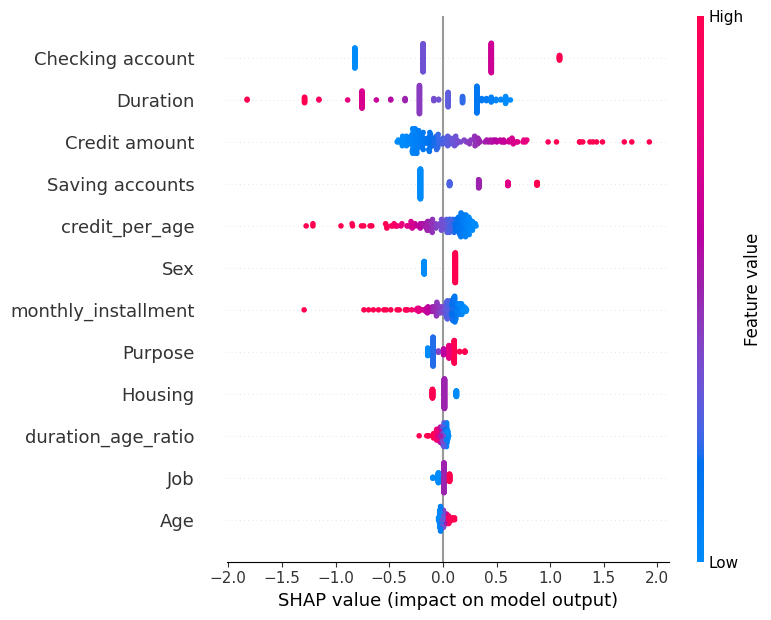

In [21]:
# ── SHAP Global Explainability — Auto Explainer ───────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Pick the right SHAP explainer based on model type
tree_models = (RandomForestClassifier, GradientBoostingClassifier,
               DecisionTreeClassifier)

try:
    from xgboost import XGBClassifier
    tree_models = tree_models + (XGBClassifier,)
except: pass
try:
    from lightgbm import LGBMClassifier
    tree_models = tree_models + (LGBMClassifier,)
except: pass

if isinstance(best_model, tree_models):
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    shap_exp = explainer(X_test)
else:
    # Linear/kernel explainer for Logistic Regression etc.
    explainer   = shap.LinearExplainer(best_model, X_train)
    shap_values = explainer.shap_values(X_test)
    sv          = shap_values
    shap_exp    = explainer(X_test)

print(f'✅ Using: {type(explainer).__name__} for {best_name}')
print('📊 SHAP Summary Plot — Global Feature Importance')
print('Each dot = one test applicant | Color = feature value | X = impact on prediction')
shap.summary_plot(sv, X_test, plot_type='dot', show=True)

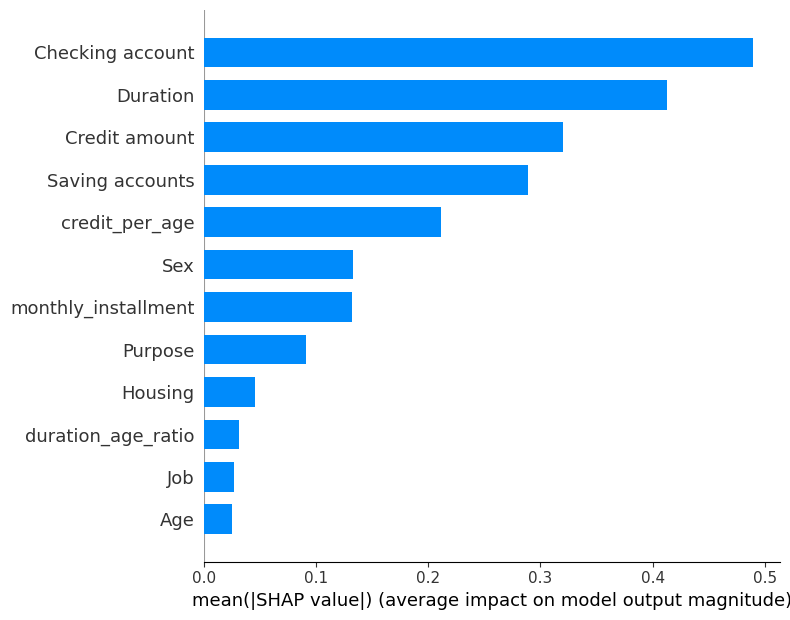

In [22]:
# ── SHAP Bar Plot — Mean Absolute Impact ─────────────────────────────
shap.summary_plot(sv, X_test, plot_type='bar', show=True)

Applicant #0
Good Credit Probability: 62.9%
Decision (t=0.20): ✅ APPROVED


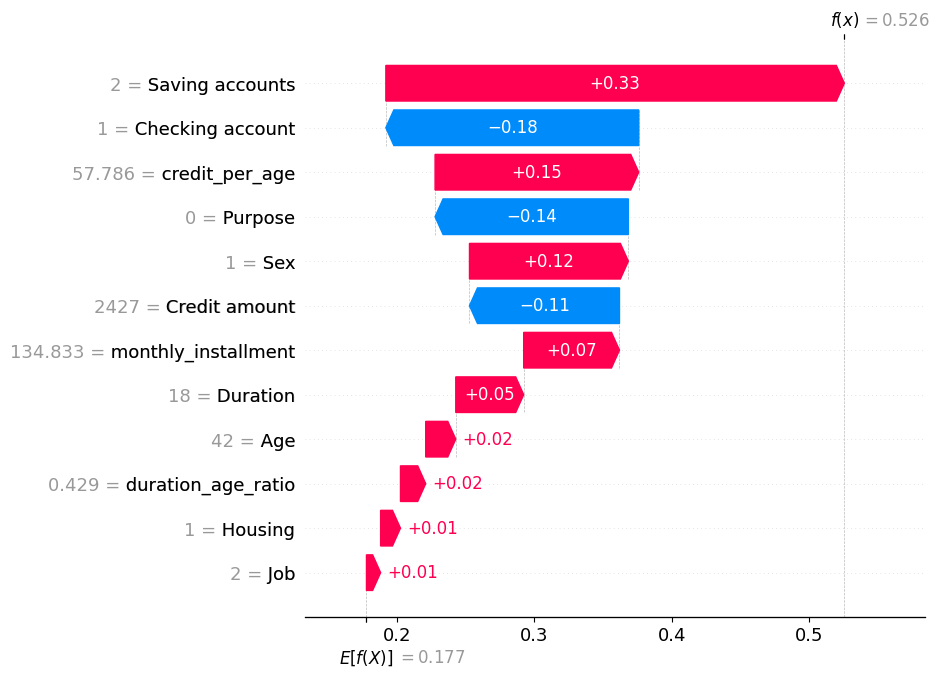

In [23]:
# ── Individual Prediction Explanation (Waterfall) ─────────────────────
applicant_idx = 0
prob     = y_prob_best[applicant_idx]
decision = '✅ APPROVED' if prob >= optimal_threshold else '❌ REJECTED'

print(f'Applicant #{applicant_idx}')
print(f'Good Credit Probability: {prob:.1%}')
print(f'Decision (t={optimal_threshold:.2f}): {decision}')

shap.waterfall_plot(shap_exp[applicant_idx], max_display=12)

How does Credit Amount interact with Duration to affect default risk?


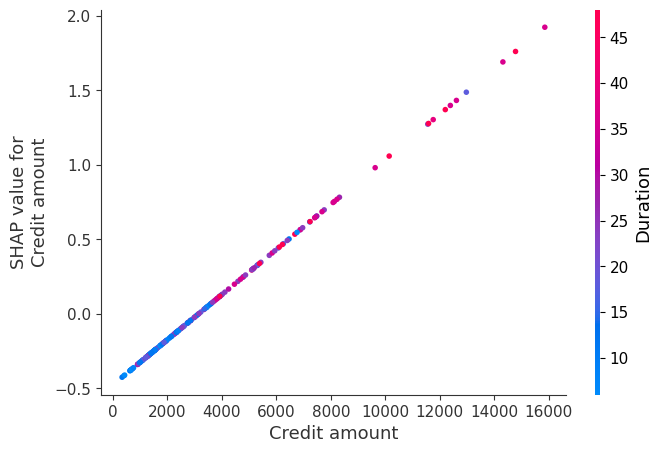

In [24]:
# ── Dependence Plot — Credit Amount x Duration ───────────────────────
print('How does Credit Amount interact with Duration to affect default risk?')
shap.dependence_plot('Credit amount', sv, X_test, interaction_index='Duration', show=True)

---
## 8 — Save Model & Deploy with Streamlit

In [25]:
# ── Save Model Artifacts ──────────────────────────────────────────────
os.makedirs('model', exist_ok=True)

with open('model/credit_risk_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('model/feature_names.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)
with open('model/optimal_threshold.pkl', 'wb') as f:
    pickle.dump(float(optimal_threshold), f)

print(f'✅ Model saved: model/credit_risk_model.pkl')
print(f'✅ Threshold:   {optimal_threshold:.2f}')
print(f'✅ Features:    {list(X.columns)}')

✅ Model saved: model/credit_risk_model.pkl
✅ Threshold:   0.20
✅ Features:    ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'monthly_installment', 'credit_per_age', 'duration_age_ratio']


In [26]:
# ── Generate app.py ──────────────────────────────────────────────────
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder

st.set_page_config(page_title="Credit Risk Scorer", page_icon="🏦", layout="wide")

@st.cache_resource
def load_model():
    with open("model/credit_risk_model.pkl",  "rb") as f: model = pickle.load(f)
    with open("model/feature_names.pkl",       "rb") as f: features = pickle.load(f)
    with open("model/optimal_threshold.pkl",   "rb") as f: threshold = pickle.load(f)
    return model, features, threshold

model, feature_names, threshold = load_model()

st.title("🏦 Credit Risk Scoring System")
st.markdown("Enter applicant details to get an instant credit risk assessment.")
st.divider()

col1, col2, col3 = st.columns(3)
with col1:
    age      = st.slider("Age", 18, 75, 35)
    duration = st.slider("Loan Duration (months)", 6, 72, 24)
    amount   = st.number_input("Credit Amount (€)", 500, 20000, 5000, step=500)
with col2:
    purpose  = st.selectbox("Purpose", ["car","furniture/equipment","radio/TV","education","business","other"])
    housing  = st.selectbox("Housing", ["own","free","rent"])
    saving   = st.selectbox("Saving Accounts", ["little","moderate","quite rich","rich","NA"])
with col3:
    checking = st.selectbox("Checking Account", ["little","moderate","rich","NA"])
    sex      = st.selectbox("Sex", ["male","female"])
    job      = st.selectbox("Job", ["0 - unskilled non-resident","1 - unskilled resident","2 - skilled","3 - highly skilled"])

if st.button("🔍  Assess Credit Risk", type="primary", use_container_width=True):
    input_data = {
        "Age": age, "Duration": duration, "Credit amount": amount,
        "Purpose": purpose, "Housing": housing, "Saving accounts": saving,
        "Checking account": checking, "Sex": sex, "Job": int(job[0])
    }
    input_df = pd.DataFrame([input_data])
    input_df["monthly_installment"] = input_df["Credit amount"] / input_df["Duration"]
    input_df["credit_per_age"]      = input_df["Credit amount"] / input_df["Age"]
    input_df["duration_age_ratio"]  = input_df["Duration"]      / input_df["Age"]

    le = LabelEncoder()
    for col in input_df.select_dtypes("object").columns:
        input_df[col] = le.fit_transform(input_df[col].astype(str))
    input_df = input_df.reindex(columns=feature_names, fill_value=0)

    prob = model.predict_proba(input_df)[0][1]
    st.divider()
    c1, c2, c3 = st.columns(3)
    c1.metric("Good Credit Probability", f"{prob:.1%}")
    c2.metric("Risk Score (0-100)", f"{int(prob*100)}")
    c3.metric("Decision Threshold", f"{threshold:.2f}")

    if prob >= threshold:
        st.success("✅ LOW RISK — Recommended: APPROVE")
    elif prob >= threshold * 0.75:
        st.warning("⚠️ MEDIUM RISK — Recommended: MANUAL REVIEW")
    else:
        st.error("❌ HIGH RISK — Recommended: REJECT")
'''

with open('app.py', 'w') as f:
    f.write(app_code.strip())

print('✅ app.py created!')
print('Run locally with: streamlit run app.py')
print('Deploy free at:   https://streamlit.io/cloud')

✅ app.py created!
Run locally with: streamlit run app.py
Deploy free at:   https://streamlit.io/cloud


---
## 9 — Summary & Key Takeaways

| Component | Detail |
|-----------|--------|
| **Dataset** | German Credit Data — 1,000 applicants, 20 features |
| **Feature Engineering** | Financial ratios, age bins, WoE/IV analysis |
| **Models Compared** | Logistic Regression, Decision Tree, Random Forest, GBM, XGBoost, LightGBM |
| **Evaluation** | Gini coefficient, AUC-ROC, Precision-Recall, Cost-sensitive threshold |
| **Interpretability** | SHAP global summary + individual waterfall explanations |
| **Deployment** | Streamlit app (`app.py`) ready for cloud deployment |

### Key Insights
- **Gini coefficient** is the primary model KPI used by banks (not accuracy)
- The **optimal threshold** differs from the default 0.5 — business costs drive the decision
- **SHAP** makes the model audit-ready and GDPR-compliant
- **WoE/IV** feature analysis mirrors real bank scorecard methodology

### Next Steps
1. **Fairness audit** — Check performance across demographic subgroups
2. **Model monitoring** — Track Gini drift in production over time
3. **Scorecard conversion** — Transform scores into a traditional points-based scorecard
4. **API wrapping** — Serve via FastAPI for integration with core banking systems